# 04 · Geografia e análise ecológica

**Perguntas:** como o desempenho se distribui no território? Municípios mais ricos têm
notas maiores?

**A restrição que define este notebook:** por causa da LGPD, o INEP removeu a chave de
ligação entre `PARTICIPANTES` (questionário socioeconômico) e `RESULTADOS` (notas).
O único cruzamento possível é **agregado por município de prova**, presente nas duas bases.
Isso é uma **análise ecológica**: as unidades são municípios, não pessoas — e correlações
ecológicas não se transferem para indivíduos (falácia ecológica).

As malhas geográficas vêm da API de malhas do IBGE (baixadas uma vez e cacheadas em
`data/raw/`).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from enem2024 import labels, plots
from enem2024.data import load

plots.setup()
GRAY = plots.BASELINE  # de-ênfase


In [2]:
import geopandas as gpd
import requests

from enem2024 import config

MALHAS = config.PROJECT_ROOT / "data" / "raw"
MALHAS.mkdir(parents=True, exist_ok=True)
API = "https://servicodados.ibge.gov.br/api/v3/malhas/paises/BR"

def fetch_malha(nivel: str) -> gpd.GeoDataFrame:
    path = MALHAS / f"malha_{nivel}.geojson"
    if not path.exists():
        r = requests.get(
            API,
            params={"formato": "application/vnd.geo+json", "qualidade": "minima",
                    "intrarregiao": nivel},
            timeout=120,
        )
        r.raise_for_status()
        path.write_bytes(r.content)
    return gpd.read_file(path)

malha_uf = fetch_malha("UF")
malha_mun = fetch_malha("municipio")
print(len(malha_uf), "UFs |", len(malha_mun), "municípios")

27 UFs | 5570 municípios


## Nota média por UF

"Média geral" = média das cinco notas de quem fez **todas** as provas (dois dias + redação), agregada dos municípios para a UF.

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


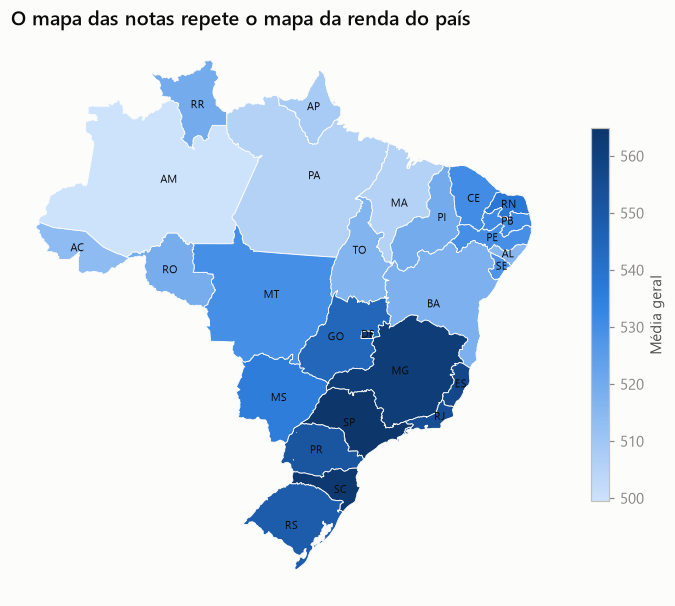

uf
AM    499.5
PA    505.8
SC    563.6
SP    564.9


In [3]:
rm = load("resultados_municipio")
uf_geral = (
    rm.assign(soma=rm.media_geral * rm.n_completos)
      .groupby("uf")[["soma", "n_completos"]].sum()
      .assign(media_geral=lambda d: d.soma / d.n_completos)
)

gdf_uf = malha_uf.assign(uf=malha_uf["codarea"].map(labels.UF_SIGLA_POR_CODIGO))
gdf_uf = gdf_uf.merge(uf_geral["media_geral"], left_on="uf", right_index=True)

fig, ax = plt.subplots(figsize=(8, 8))
gdf_uf.plot(column="media_geral", cmap=plots.CMAP_SEQ, linewidth=0.6,
            edgecolor=plots.SURFACE, legend=True, ax=ax,
            legend_kwds={"shrink": 0.55, "label": "Média geral"})
ax.set_axis_off()
ax.set_title("O mapa das notas repete o mapa da renda do país", loc="left")
for _, row in gdf_uf.iterrows():
    pt = row.geometry.representative_point()
    ax.annotate(row["uf"], (pt.x, pt.y), ha="center", va="center",
                fontsize=7, color=plots.INK)
plots.save_fig(fig, "09_mapa_uf")
plt.show()

print(uf_geral["media_geral"].sort_values().round(1).iloc[[0, 1, -2, -1]].to_string())

## Nota média por município

Apenas municípios com pelo menos 30 participantes que fizeram todas as provas; os demais ficam em cinza.

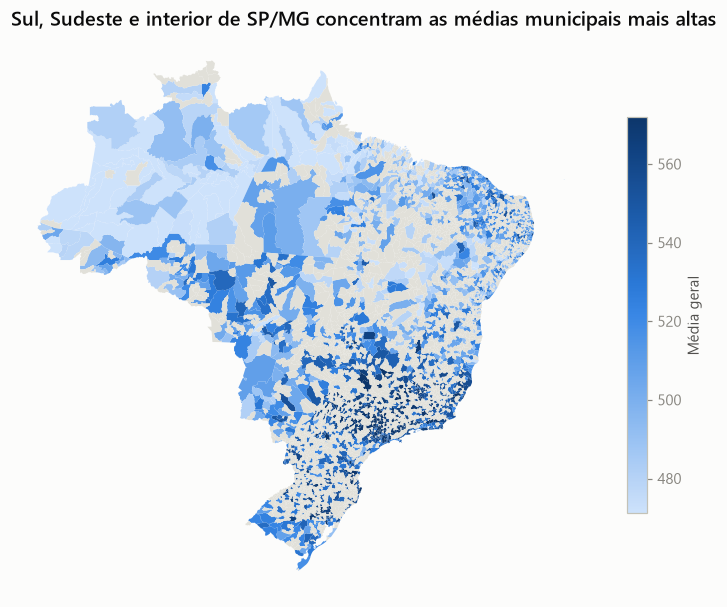

In [4]:
mun = rm.loc[rm.n_completos >= 30, ["co_municipio", "media_geral"]].copy()
mun["co_municipio"] = mun["co_municipio"].astype(str)

gdf_mun = malha_mun.merge(mun, left_on="codarea", right_on="co_municipio", how="left")

# percentis 5–95 esticam o contraste; sem isso o mapa fica todo azul-médio
vmin, vmax = mun["media_geral"].quantile([0.05, 0.95])

fig, ax = plt.subplots(figsize=(8.5, 8.5))
gdf_mun.plot(column="media_geral", cmap=plots.CMAP_SEQ, linewidth=0, ax=ax,
             vmin=vmin, vmax=vmax, legend=True,
             legend_kwds={"shrink": 0.55, "label": "Média geral"},
             missing_kwds={"color": plots.GRID, "label": "menos de 30 participantes"})
ax.set_axis_off()
ax.set_title("Sul, Sudeste e interior de SP/MG concentram as médias municipais mais altas",
             loc="left")
plots.save_fig(fig, "10_mapa_municipios")
plt.show()

## Municípios mais ricos têm notas maiores?

Cada ponto é um município com ≥100 participantes completos. O eixo x vem da base de
PARTICIPANTES (% de inscritos com renda familiar acima de 5 SM); o eixo y vem da base
de RESULTADOS (média geral). É o cruzamento que a LGPD permite.

1731 municípios | Pearson r = 0.80 | Spearman rho = 0.83


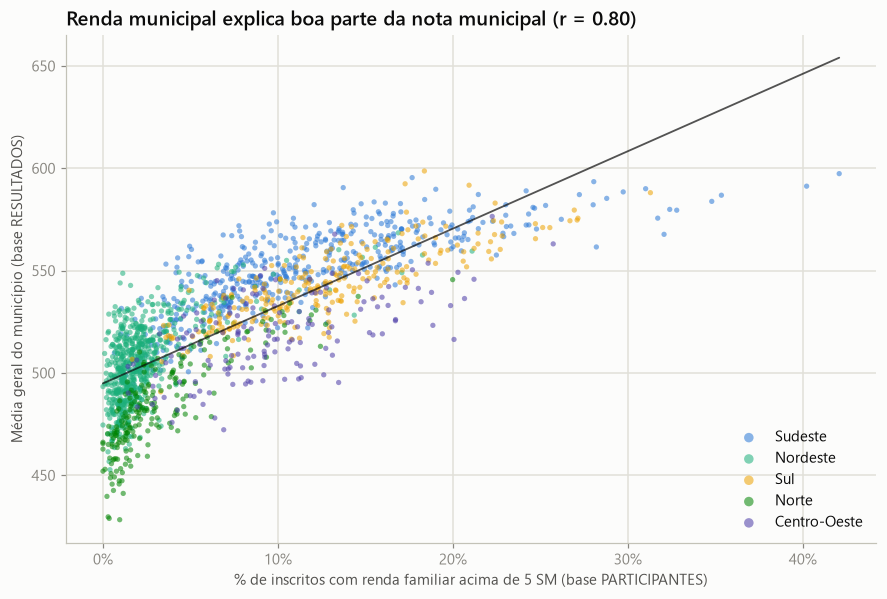

In [5]:
pm = load("participantes_municipio")
eco = (
    rm.merge(pm[["co_municipio", "prop_renda_5sm_mais", "prop_mae_superior", "prop_wifi"]],
             on="co_municipio")
      .query("n_completos >= 100")
      .dropna(subset=["prop_renda_5sm_mais", "media_geral"])
)
r = eco.prop_renda_5sm_mais.corr(eco.media_geral)
rho = eco.prop_renda_5sm_mais.corr(eco.media_geral, method="spearman")
print(f"{len(eco)} municípios | Pearson r = {r:.2f} | Spearman rho = {rho:.2f}")

cores_regiao = dict(zip(["Sudeste", "Nordeste", "Sul", "Norte", "Centro-Oeste"],
                        plots.CATEGORICAL[:5]))
regiao = eco["uf"].map(labels.REGIAO_POR_UF)

fig, ax = plt.subplots(figsize=(9.5, 6))
for nome, cor in cores_regiao.items():
    d = eco[regiao == nome]
    ax.scatter(d.prop_renda_5sm_mais, d.media_geral, s=12, alpha=0.55,
               color=cor, label=nome, edgecolors="none")
coef = np.polyfit(eco.prop_renda_5sm_mais, eco.media_geral, 1)
xs = np.linspace(eco.prop_renda_5sm_mais.min(), eco.prop_renda_5sm_mais.max(), 50)
ax.plot(xs, np.polyval(coef, xs), color=plots.INK, linewidth=1.2, alpha=0.7)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("% de inscritos com renda familiar acima de 5 SM (base PARTICIPANTES)")
ax.set_ylabel("Média geral do município (base RESULTADOS)")
ax.set_title(f"Renda municipal explica boa parte da nota municipal (r = {r:.2f})")
ax.legend(title="", markerscale=1.8, loc="lower right")
plots.save_fig(fig, "11_ecologica_renda")
plt.show()

In [6]:
top = (
    eco.nlargest(10, "media_geral")
       [["municipio", "uf", "n_completos", "media_geral", "prop_renda_5sm_mais"]]
       .assign(media_geral=lambda d: d.media_geral.round(1),
               prop_renda_5sm_mais=lambda d: (d.prop_renda_5sm_mais * 100).round(1))
       .rename(columns={"prop_renda_5sm_mais": "% renda 5SM+"})
)
top

,municipio,uf,n_completos,media_geral,% renda 5SM+
0,Veranópolis,RS,340,598.7,18.4
1370,Valinhos,SP,1625,597.4,42.1
1132,Itaúna,MG,1048,595.5,17.7
9,São José dos Campos,SP,9829,593.5,28.1
788,Arroio do Meio,RS,138,592.4,17.3
756,Lajeado,RS,1075,591.7,20.9
320,Vinhedo,SP,1004,591.3,40.2
1106,Formiga,MG,843,590.6,13.7
87,Niterói,RJ,10583,590.0,31.0
372,Timóteo,MG,1215,589.8,19.0


## Regressão múltipla: renda ainda importa controlando o resto?

A correlação bivariada não separa renda de tudo que anda junto com ela. A regressão
múltipla (OLS) coloca quatro características municipais lado a lado — % renda 5 SM+,
% mães com superior, % com wi-fi em casa e % de alunos de escola privada — todas
**padronizadas** (z-score), para que os coeficientes sejam comparáveis entre si.

Continua sendo uma análise **ecológica** (municípios, não pessoas), e os preditores são
fortemente correlacionados entre si — o objetivo é descritivo, não causal.

In [7]:
import statsmodels.api as sm

preditores = ["prop_renda_5sm_mais", "prop_mae_superior", "prop_wifi", "prop_escola_privada"]
dados = eco[["media_geral", *preditores]].dropna()
z = (dados - dados.mean()) / dados.std()

modelo = sm.OLS(z["media_geral"], sm.add_constant(z[preditores])).fit()
print(modelo.summary2().tables[1].round(3))
print(f"\nR² ajustado: {modelo.rsquared_adj:.2f} | n = {int(modelo.nobs)} municípios")
print("\nCorrelação entre os preditores (por que os betas exigem cuidado):")
print(dados[preditores].corr().round(2).to_string())

                     Coef.  Std.Err.       t  P>|t|  [0.025  0.975]
const               -0.000     0.011  -0.000  1.000  -0.022   0.022
prop_renda_5sm_mais  0.370     0.029  12.922  0.000   0.314   0.426
prop_mae_superior   -0.054     0.024  -2.253  0.024  -0.100  -0.007
prop_wifi            0.441     0.014  31.069  0.000   0.414   0.469
prop_escola_privada  0.263     0.018  14.996  0.000   0.228   0.297

R² ajustado: 0.79 | n = 1731 municípios

Correlação entre os preditores (por que os betas exigem cuidado):
                     prop_renda_5sm_mais  prop_mae_superior  prop_wifi  prop_escola_privada
prop_renda_5sm_mais                 1.00               0.88       0.62                 0.77
prop_mae_superior                   0.88               1.00       0.60                 0.64
prop_wifi                           0.62               0.60       1.00                 0.50
prop_escola_privada                 0.77               0.64       0.50                 1.00


O modelo confirma que **renda não é um mero proxy**: mesmo controlando escolaridade da mãe,
wi-fi e escola privada, o beta padronizado da renda segue alto (β ≈ 0,37). O preditor mais
forte é o **wi-fi em casa** (β ≈ 0,44) — um indicador de infraestrutura que separa municípios
de forma mais limpa que a renda declarada. Já o coeficiente **negativo** da escolaridade da
mãe (β ≈ −0,05) é um artefato clássico de **multicolinearidade**: ela correlaciona 0,88 com a
renda, e coeficientes de preditores quase redundantes são instáveis — mais um lembrete de que
o modelo descreve, não explica.

## A falácia ecológica — por que este resultado deve ser lido com cuidado

A correlação (r ≈ 0,80) e a regressão valem para **municípios**, não para pessoas. Dois
motivos para cautela:

1. **Agregação amplifica**: médias municipais suavizam a variação individual, então a
   correlação ecológica costuma ser bem maior do que a individual equivalente.
2. **Composição ≠ efeito**: um município "rico" também tem mais escolas privadas, mais mães
   com ensino superior e menos abstenção — variáveis que andam juntas e não podem ser
   separadas sem o vínculo individual, que a LGPD removeu dos microdados a partir de 2020/2024.

Ainda assim, o padrão é consistente com décadas de literatura sobre desigualdade
educacional no Brasil — e o fato de o INEP ter removido a chave de ligação é em si um
achado documentado neste projeto.

## Conclusões

1. **O mapa das notas repete o mapa da renda**: as maiores médias estão em SP/MG/Sul e nos
   municípios-sede de IFs e colégios militares; as menores, no interior do Norte/Nordeste.
2. Entre municípios com ≥100 participantes completos, **% de renda alta explica boa parte da
   variação da média geral** (r ≈ 0,80; ρ ≈ 0,83).
3. Na **regressão múltipla** (R² aj. ≈ 0,79), renda (β ≈ 0,37) e wi-fi em casa (β ≈ 0,44)
   seguem fortes lado a lado; escola privada soma β ≈ 0,26; o sinal invertido da escolaridade
   da mãe expõe a multicolinearidade entre os preditores (r = 0,88 com renda).
4. O resultado é **ecológico por imposição da LGPD** — leia as ressalvas acima.